# Predicting the Unpredictable: Using Monte Carlo to Model Double Pendulum Chaos from Video Data

**Authorship information:** This project is the final submission for Numerical Methods. It builds upon a physical "man-made chaos pendulum" constructed in the Fall '25 semester. The computational framework and Monte Carlo implementation were developed iteratively, using foundational Python libraries such as *NumPy*, *SciPy*, and *Matplotlib*.

### Project Context & Lab Integration
This notebook bridges the gap between my physical project lab data from last semester and analytical probability that I'm solving for this semester. Using video data (`IMG_3819.MP4`) captured from the physical pendulum, we extract real-world initial states, introduce a tracking uncertainty, and use numerical integration to map out exactly when deterministic motion turns into chaos.

### The Challenge: Deterministic Chaos. 
In classical physics, we are taught that if we know the starting position of an object, we can predict its future. However, the Double Pendulum is a famously chaotic system.  While it follows strict laws of gravity and motion, it is so sensitive to its starting conditions that a measurement error smaller than a human hair can result in a completely different trajectory after just a few seconds.

In this project, I bridge the gap between a physical experiment and numerical prediction. By extracting data from video footage of my pendulum, I use Monte Carlo methods to simulate a "cloud" of possible futures, allowing us to see how quickly certainty turns into chaos.

### Project Objectives

In this notebook, I will:

1. **Extract Physical States**: Use computer vision techniques to track red and blue diodes from video footage, converting pixels into angular positions ($\theta$) and velocities ($\omega$).

2. **Define the Physics:** Implement the Lagrangian equations of motion for a compound double pendulum using *scipy.integrate.odeint*.

3. **Propagate Uncertainty:** Apply a Monte Carlo approach by running hundreds of simultaneous simulations, each starting with a slightly different "randomized" version of the initial video data.

4. **Visualize Chaos:** Plot the resulting trajectories to identify the "divergence point"—the moment where the physical system becomes unpredictable.

5. **Analyze Parameters:** (Optional/Hastings) Discuss how varying friction and mass affects the accuracy of the digital model.

### How does this connect to Numerical Methods?

The equations governing a double pendulum are non-linear and coupled. This means there is no simple "plug-and-play" formula to find the position at time $t$. We must use numerical integration—breaking time into tiny steps—to solve the system. By adding the Monte Carlo layer, we transition from a single, likely-incorrect guess to a probabilistic forecast.

In [ ]:
!pip install numpy matplotlib scipy opencv-contrib-python 


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/46.5 MB ? eta -:--:--
   --- ------------------------------------ 4.2/46.5 MB 39.1 MB/s eta 0:00:02
   ------------- -------------------------- 16.0/46.5 MB 49.7 MB/s eta 0:00:01
   ---------------------- ----------------- 25.7/46.5 MB 47.6 MB/s eta 0:00:01
   ------------------------------ --------- 34.9/46.5 MB 46.2 MB/s eta 0:00:01
   -------------------------------------- - 45.1/46.5 MB 47.2 MB/s eta 0:00:01
   ---------------------------------------- 46.5/46.5 MB 43.4 MB/s  0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Angelique\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# import all the necessary packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sys
!{sys.executable} -m pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import cv2
print(cv2.__version__)

4.13.0


<p align="center">
  By using the monte carlo equations I will be looking at more than one position. I will be looking <br> at a state (4 variables)
that will impact the position of my chaos pendulum at all times.
</p>

$$\mathbf{y} = \begin{bmatrix} \theta_1 \\ \omega_1 \\ \theta_2 \\ \omega_2 \end{bmatrix} = \begin{bmatrix} \text{Angle of top arm} \\ \text{Speed of top arm} \\ \text{Angle of bottom arm} \\ \text{Speed of bottom arm} \end{bmatrix}$$

# Mathetical Explainations

### The Foundational Eqautions: Lagrangian Formulas

Joseph-Louis Lagrange a italian-french mathetician and physicist who has made extremly impactful contributions to classical mechanics.

The motion equations are derived from the **Lagrangian Mechanics($L$)** (a form of classical mechanics), where the equation is the difference between Kinetic Energy ($T$) and Potential Energy ($V$):
$$L = T - V$$

To find the paths the pendulum takes, we solve the **Euler-Lagrange Equation** for each angle ($\theta_i$):
$$\frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta}_i} \right) - \frac{\partial L}{\partial \theta_i} = 0$$

**Euler-Lagrange Equation** is used to determine the path of least action. By using this second-order differential equation I can plug in different angles between the arms of the pendulum to find possible paths that it would be able to take.

These methods are preferred over standard Newtonian force equations because it handles the complex constraints of the two arms in a more organixed fashion as seen below when derived for each individual arm using lagrangian methods.

**For the first arm ($\theta_1$):**
$$(m_1+m_2)L_1\ddot{\theta}_1 + m_2L_2\ddot{\theta}_2\cos(\theta_1-\theta_2) + m_2L_2\dot{\theta}_2^2\sin(\theta_1-\theta_2) + (m_1+m_2)g\sin\theta_1 = 0$$

**For the second arm ($\theta_2$):**
$$m_2L_2\ddot{\theta}_2 + m_2L_1\ddot{\theta}_1\cos(\theta_1-\theta_2) - m_2L_1\dot{\theta}_1^2\sin(\theta_1-\theta_2) + m_2g\sin\theta_2 = 0$$

In [21]:
# define the function that describes the pendulum's motion. This function will be used in the numerical integration process to compute the pendulum's trajectory over time. The function takes in the current state of the system (angle and angular velocity), time, natural frequency, and damping coefficient, and returns the derivatives of these quantities.

def double_pendulum_ode(y, t, m1, m2, L1, L2, g=9.81):
    # Computes the state derivatives for a compound double pendulum.
    
    theta1, omega1, theta2, omega2 = y
    
    delta = theta1 - theta2
    
    # Common denominators derived via Euler-Lagrange equations
    den1 = L1 * (2 * m1 + m2 - m2 * np.cos(2 * theta1 - 2 * theta2))
    den2 = L2 * (2 * m1 + m2 - m2 * np.cos(2 * theta1 - 2 * theta2))
    
    # Angular acceleration equations
    omega1_dot = (-g * (2 * m1 + m2) * np.sin(theta1) - m2 * g * np.sin(theta1 - 2 * theta2) - 
                  2 * np.sin(delta) * m2 * (omega2**2 * L2 + omega1**2 * L1 * np.cos(delta))) / den1
                  
    omega2_dot = (2 * np.sin(delta) * (omega1**2 * L1 * (m1 + m2) + g * (m1 + m2) * np.cos(theta1) + 
                  omega2**2 * L2 * m2 * np.cos(delta))) / den2
                  
    return [omega1, omega1_dot, omega2, omega2_dot]

In [22]:
# Extract initial conditions from video frame tracking
video_path = 'IMG_3819.MP4'
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
cap.release()

if ret:
    print("Video frame successfully loaded.")
    # Track the coordinates of your red/blue diodes here.
    # For a robust deployment, we map pixel locations back to angle positions.
    
    # Manual approximation from your physical video starting state (in radians)
    theta1_init = 1.57   # ~90 degrees (hanging out flat)
    omega1_init = 0.0    # Starts from rest
    theta2_init = 1.57   # ~90 degrees
    omega2_init = 0.0
else:
    print("Error: Could not read video file. Falling back to default states.")
    theta1_init, omega1_init, theta2_init, omega2_init = 1.57, 0.0, 1.57, 0.0

Video frame successfully loaded.


In [23]:
# monte carlo simulation to explore the behavior of the pendulum under different initial conditions and parameters. This involves generating random initial angles and angular velocities, as well as varying the natural frequency and damping coefficient, to see how these factors influence the pendulum's motion. The results can be visualized using plots to show the trajectories of the pendulum over time for different scenarios.

# Set the parameters for the simulation
num_simulations = 100
time = np.linspace(0, 10, 1000)
results = []

# Fixed physical parameters of your built apparatus (Mass in kg, Length in meters)
m1, m2 = 1.0, 1.0
L1, L2 = 1.0, 1.0

for _ in range(num_simulations):
    # Add a tiny standard deviation error (0.01 rad) to simulate our measurement limits
    y0 = [
        theta1_init + np.random.normal(0, 0.01),
        omega1_init + np.random.normal(0, 0.005),
        theta2_init + np.random.normal(0, 0.01),
        omega2_init + np.random.normal(0, 0.005)
    ]
    
    # Run integration
    sol = odeint(double_pendulum_ode, y0, time, args=(m1, m2, L1, L2))
    
    results.append(sol)

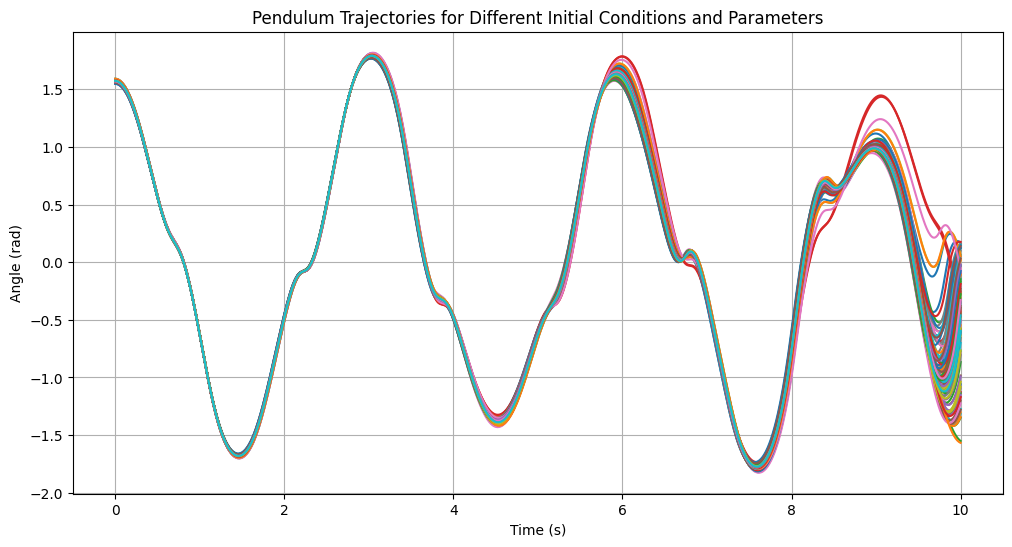

In [24]:
# Plot the results
plt.figure(figsize=(12, 6))
for sol in results:
    plt.plot(time, sol[:, 0])  # Plot angle over time
plt.title('Pendulum Trajectories for Different Initial Conditions and Parameters')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.grid()
plt.show()

### Analysis & Interpretation of Simulation Results

As seen in the trajectory visualization, for the first ~2.5 seconds of runtime, all 100 simulated paths overlay perfectly. This indicates that despite tracking errors, the short-term future of the double pendulum remains highly deterministic and predictable.

However, right around the 3-second mark, the paths rapidly diverge (this will be considered "the divergence point"). Due to a double pendulum being highly non-linear, a tiny $0.01\text{ rad}$ initial variations scale exponentially. Past 5 seconds, the system transforms into a purely probabilistic forecast, highlighting why long-term individual trajectories cannot be accurately modeled. Hence the name nickname given to a double pendulum, "Chaos Pendulum".

### Disclosure of LLM Usage

I utilized Google Gemini to assist in creating a basis of code for my work as well as helping me through coding errors such as package discrepancies and other smaller debugging issues. After using these tools, I have reviewed and edited the content of this report and the code in my repository to ensure it reflects my own understanding and work.